# 01 · Beijing PM2.5 — Advanced EDA

## Part 1 — Advanced EDA (pollution, missingness & meteorology)

Three threads, two of them new to this collection:

1. the **pollution distribution** — heavy right-skew, and what "99 µg/m³ on average" means against
   health guidelines;
2. the **missing-data mechanism** — *why* are values missing, and is it safe to impute? (the
   distinctive theme of this dataset);
3. the **meteorology of pollution** — how weather *drives* PM2.5 (wind clears it, humidity traps it),
   the multivariate story.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

df = data.clean()
print('rows:', len(df), '| pm25 present:', int(df.pm25.notna().sum()))

setup ok | numpy 2.1.3 | pandas 2.3.3
rows: 43824 | pm25 present: 41757


### 1. The pollution target — heavy right-skew

PM2.5 is a concentration: bounded below by 0, with a long tail of severe-pollution hours. The four-
view battery shows the skew; a **log transform** tames it (the usual move for concentrations). For
context, the **WHO 24-h guideline is 15 µg/m³** — Beijing's *mean* is ~7× that.

n                  41757.0
mean                  98.6
std                   92.1
skew                   1.8
excess_kurtosis        4.8
min                    0.0
median                72.0
max                  994.0


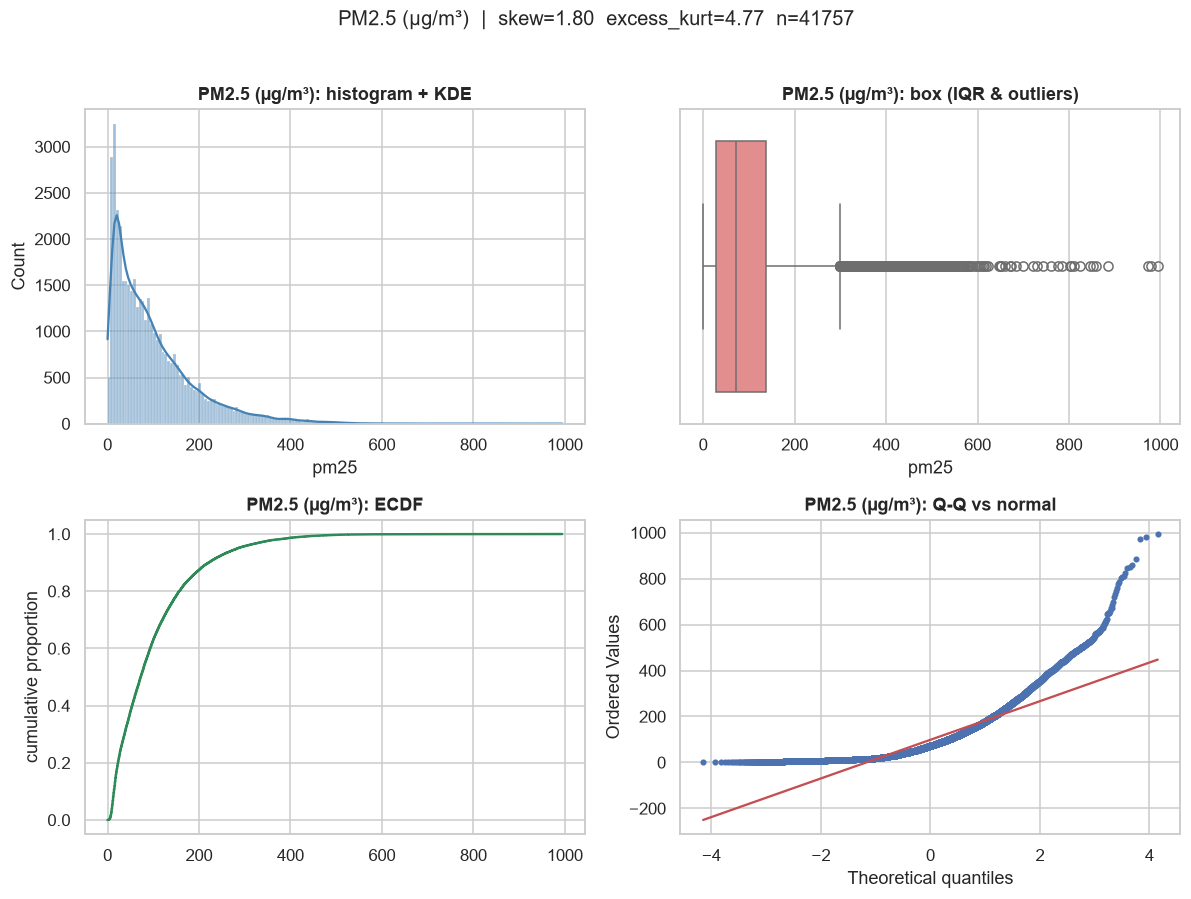


WHO 24h guideline = 15 µg/m³ | 84% of hours exceed it | hours above 'hazardous' 250: 7.0%


In [2]:
print(eda.moments(df["pm25"]).round(1).to_string())
fig = eda.four_view(df["pm25"].dropna(), "PM2.5 (µg/m³)", "p1_fourview.png"); plt.show()
print("\nWHO 24h guideline = %.0f µg/m³ | %.0f%% of hours exceed it | hours above 'hazardous' 250: %.1f%%"
      % (data.WHO_24H, 100*(df.pm25 > data.WHO_24H).mean(), 100*(df.pm25 > 250).mean()))

In [3]:
# The worst episodes are real history — e.g. the January 2013 "airpocalypse".
daily = df["pm25"].resample("D").mean()
print("worst pollution days (daily mean µg/m³):")
print(daily.nlargest(5).round(0).to_string())

worst pollution days (daily mean µg/m³):
datetime
2013-01-12    552.0
2011-02-21    494.0
2014-01-16    458.0
2014-02-25    443.0
2013-01-29    438.0


### 2. Why are values missing? — the mechanism

Before imputing anything, ask *why* data is missing (Part 2 will then choose a method):

- **MCAR** (missing completely at random) — unrelated to anything; safe to drop/impute simply.
- **MAR** (missing at random) — related to *observed* variables; impute using them.
- **MNAR** (missing not at random) — related to the *missing value itself* (e.g. the sensor fails
  *because* pollution is extreme); the dangerous case.

These are **sensor outages**, so they're plausibly unrelated to the pollution level. We sanity-check
**MCAR** by comparing the weather on missing vs present hours — if they look the same, missingness
isn't tied to observed conditions.

In [4]:
miss = df.pm25.isna()
cmp = pd.DataFrame({"present": df.loc[~miss, data.WEATHER].mean(),
                    "missing": df.loc[miss, data.WEATHER].mean()}).round(1)
cmp["% diff"] = (100*(cmp["missing"]/cmp["present"] - 1)).round(0)
print(cmp.to_string())
print("\nWeather is similar on missing vs present hours -> consistent with ~MCAR (sensor faults),")
print("BUT the 155h-long runs can't be honestly interpolated -> Part 2 evaluates real methods.")

      present  missing  % diff
DEWP      1.8      3.2    78.0
TEMP     12.4     13.4     8.0
PRES   1016.4   1016.5     0.0
Iws      23.9     24.3     2.0
Is        0.1      0.0  -100.0
Ir        0.2      0.2     0.0

Weather is similar on missing vs present hours -> consistent with ~MCAR (sensor faults),
BUT the 155h-long runs can't be honestly interpolated -> Part 2 evaluates real methods.


### 3. The meteorology of pollution — the multivariate story

PM2.5 isn't random: **weather disperses or traps it**. The clearest driver is **wind** — strong winds
(`Iws`) blow pollution away — while humidity (`DEWP`) and stagnant air trap it. Wind *direction*
matters too: clean northerly (NW) air vs stagnant/​southerly conditions.

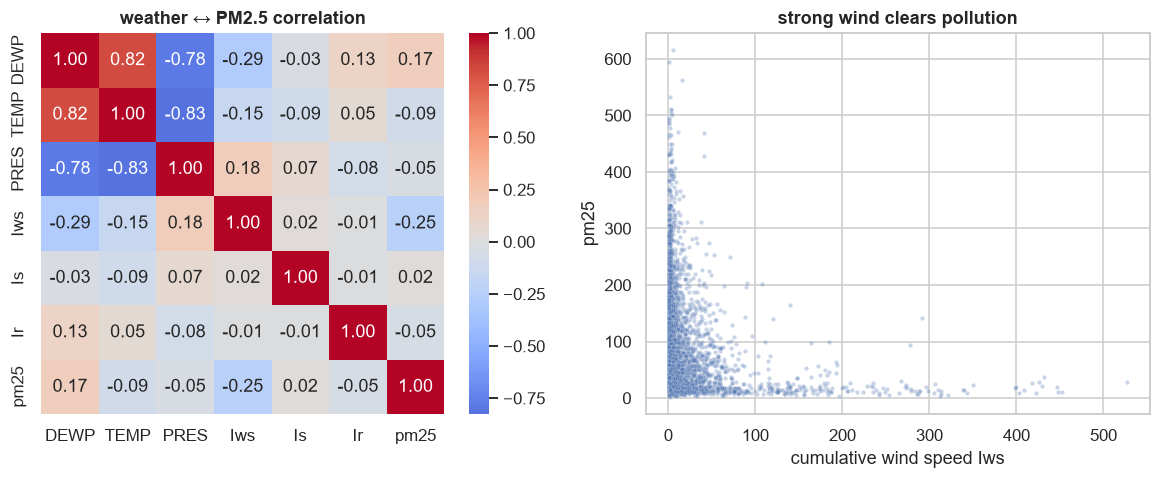

PM2.5 vs wind speed corr = -0.25 (disperses) | vs dew point = 0.17 (traps)


In [5]:
num = df[data.WEATHER + ["pm25"]].dropna()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[0]); ax[0].set_title("weather ↔ PM2.5 correlation")
samp = df.dropna(subset=["pm25"]).sample(3000, random_state=0)
sns.scatterplot(x="Iws", y="pm25", data=samp, s=8, alpha=.3, ax=ax[1]); ax[1].set_title("strong wind clears pollution"); ax[1].set_xlabel("cumulative wind speed Iws")
eda.savefig(fig, "p1_weather.png"); plt.show()
print("PM2.5 vs wind speed corr = %.2f (disperses) | vs dew point = %.2f (traps)"
      % (num.pm25.corr(num.Iws), num.pm25.corr(num.DEWP)))

In [6]:
by_wind = df.groupby("wind_dir", observed=True).pm25.mean().sort_values()
print("mean PM2.5 by wind direction (µg/m³):"); print(by_wind.round(0).to_string())
print("-> %s winds are cleanest, %s the most polluted." % (by_wind.index[0], by_wind.index[-1]))

mean PM2.5 by wind direction (µg/m³):
wind_dir
NW     70.0
NE     90.0
SE    111.0
cv    126.0
-> NW winds are cleanest, cv the most polluted.


### 4. Seasonality preview — winter is worse

Pollution has a strong **yearly** cycle (winter coal heating + stagnant air) and a **daily** cycle.
This previews the multi-seasonal time-series work to come.

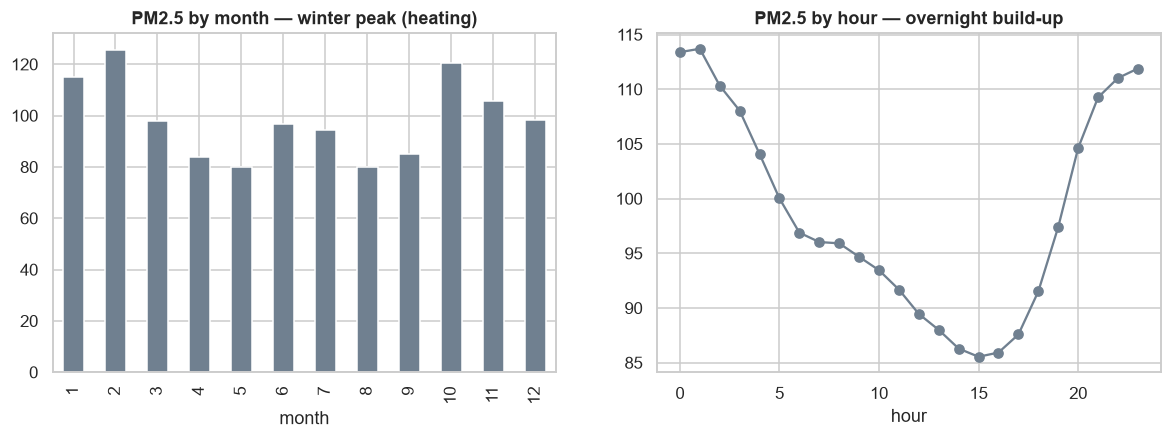

worst month: 2 (126) vs best: 8 (80) µg/m³


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df.groupby(df.index.month).pm25.mean().plot(kind="bar", ax=ax[0], color="slategray"); ax[0].set_title("PM2.5 by month — winter peak (heating)"); ax[0].set_xlabel("month")
df.groupby(df.index.hour).pm25.mean().plot(ax=ax[1], marker="o", color="slategray"); ax[1].set_title("PM2.5 by hour — overnight build-up"); ax[1].set_xlabel("hour")
eda.savefig(fig, "p1_seasonality.png"); plt.show()
w = df.groupby(df.index.month).pm25.mean()
print("worst month: %d (%.0f) vs best: %d (%.0f) µg/m³" % (w.idxmax(), w.max(), w.idxmin(), w.min()))

### Takeaways

- **PM2.5 is heavily right-skewed** (a √/log transform helps); Beijing averages ~99 µg/m³ — **84% of
  hours breach the WHO guideline** — with real "airpocalypse" extremes (Jan 2013).
- **The missingness is structured**: 2,067 gaps, mostly single hours but with **outages up to 155 h**.
  Weather looks the same on missing vs present hours → plausibly **MCAR**, but the long runs rule out
  naive interpolation — *how* you impute will matter.
- **Weather drives pollution**: wind **disperses** it (corr −0.25, clean NW winds), humidity **traps**
  it (+0.17) — a genuine multivariate, causal-ish structure the forecasting will exploit.
- Strong **winter (heating) and daily** seasonality previews the time-series work.

**Next — Part 2 (Missing-Data Imputation):** the centerpiece — compare forward-fill, time
interpolation, seasonal, **KNN**, and **MICE** imputation; *evaluate* them by masking known values;
and show why the 155-hour gaps need special care.